# Simulated Annealing Repeat Reliability

This tutorial walks through repeat-reliability analysis for the bundled Simulated Annealing data. The practical question is: which sweep settings have reliable `R99` and `CETS` estimates, and where would additional repeats make the recommendation more trustworthy?

Learning goals:

1. Convert the tutorial performance-ratio target into a per-instance energy threshold for success.
2. Run `stochastic_benchmark.run_RepeatReliability` on real SA run data.
3. Read `R99`, `CETS`, confidence intervals, and required-repeat diagnostics.
4. Use the diagnostics to plan targeted reruns instead of rerunning the whole grid.
5. Relate the SA results to the reliability argument in Noori et al., "Statistical analysis for per-instance evaluation of stochastic optimizers: Avoiding unreliable conclusions," *Physical Review Applied* 25, no. 3 (2026): 034081; arXiv:2503.16589v2.


## Step 1: Define success for the SA runs

The raw data file `results/all_raw_runs.pkl` stores repeated SA energies for many sweep counts. This tutorial uses three instances to keep execution fast. For each instance we compute:

- `best_value`: the best energy observed in the bundled runs;
- `random_value`: a reproducible random-sampler baseline;
- `success_energy_threshold`: the energy cutoff induced by the tutorial quality target.

A repeat is counted as successful when its energy is at or below this threshold. That turns the SA output into Bernoulli success/failure data, which is the input needed for repeat reliability.


In [1]:
import json
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import dimod
import numpy as np
import pandas as pd

notebook_cwd = Path.cwd().resolve()
if (notebook_cwd / "results" / "all_raw_runs.pkl").is_file():
    example_dir = notebook_cwd
    repo_root = example_dir.parents[1]
else:
    repo_root = notebook_cwd
    example_dir = (repo_root / "examples" / "Simulated_Annealing").resolve()

for path in [repo_root / "src", example_dir]:
    path_text = str(path)
    if path_text not in sys.path:
        sys.path.insert(0, path_text)

from reliability_analysis import (
    DEFAULT_QUALITY_TARGET,
    attach_quality_thresholds,
    load_selected_raw_runs,
    quality_threshold_from_baseline,
)

instance_ids = [0, 1, 2]
quality_target = DEFAULT_QUALITY_TARGET
num_reads = 1000
num_variables = 100
pd.options.display.max_columns = 20


def build_tutorial_bqm(instance_id, *, num_variables=100):
    np.random.seed(instance_id)
    J = np.random.rand(num_variables, num_variables)
    J = np.triu(J, 1)
    h = np.random.rand(num_variables)
    return dimod.BinaryQuadraticModel.from_ising(h, J, offset=0.0)


def random_energy_for_instance(instance_id, *, num_reads=1000, num_variables=100):
    model_random = build_tutorial_bqm(instance_id, num_variables=num_variables)
    samples = dimod.RandomSampler().sample(
        model_random,
        num_reads=num_reads,
        seed=instance_id,
    )
    return float(np.asarray(samples.data_vectors["energy"]).mean())


runs = load_selected_raw_runs(example_dir, instance_ids)
instance_baselines = {}
for instance_id in instance_ids:
    instance_runs = runs[runs["instance"] == instance_id]
    instance_baselines[instance_id] = {
        "best_value": float(instance_runs["energy"].min()),
        "random_value": random_energy_for_instance(
            instance_id,
            num_reads=num_reads,
            num_variables=num_variables,
        ),
    }

baseline_table = (
    pd.DataFrame.from_dict(instance_baselines, orient="index")
    .rename_axis("instance")
    .reset_index()
)
baseline_table["quality_target"] = quality_target
baseline_table["success_energy_threshold"] = baseline_table.apply(
    lambda row: quality_threshold_from_baseline(
        row["best_value"],
        row["random_value"],
        quality_target=quality_target,
    ),
    axis=1,
)
baseline_table


,instance,best_value,random_value,quality_target,success_energy_threshold
0,0,-239.359143,-1.207017,0.95,-227.451537
1,1,-244.676830,0.621088,0.95,-232.411934
2,2,-237.949914,-1.033347,0.95,-226.104086


## Step 2: Run the initial repeat-reliability report

The report uses the observed number of successful repeats at each `(instance, sweeps)` pair to estimate `R99`: the number of independent repeats needed to see at least one success with 99 percent confidence. `CETS` scales `R99` by the sweep count, so lower values are better.

The most important diagnostic fields are:

- `current_repeats`: how many repeats are in the data at that sweep count;
- `required_repeats`: how many repeats are needed to keep the maximum relative error below the target;
- `reliability_status`: `reliable` when the current repeats meet that target, otherwise `needs_more_trials`;
- `statistically_unresolved`: whether this row still overlaps the best interval for the comparison.


In [2]:
import stochastic_benchmark as SB

from reliability_analysis import (
    run_reliability_analysis,
    select_reliability_diagnostics,
)


def make_benchmark():
    return SB.stochastic_benchmark(
        parameter_names=["sweeps"],
        here=str(example_dir),
        instance_cols=["instance"],
        response_key="energy",
        response_dir=-1,
        recover=False,
        smooth=False,
    )


reliability_runs = attach_quality_thresholds(
    runs,
    instance_baselines,
    quality_target=quality_target,
)

report = run_reliability_analysis(
    make_benchmark(),
    reliability_runs,
    quality_target=quality_target,
    relative_error_threshold=0.10,
)
diagnostics = select_reliability_diagnostics(report)

assert not diagnostics.empty
assert report["reliability_status"].eq("needs_more_trials").any()
assert report["statistically_unresolved"].any()

diagnostics


,instance,sweeps,current_resource,current_repeats,required_repeats,additional_repeats_required,p_ci_lower,p_ci_upper,R_c,R_c_ci_lower,R_c_ci_upper,R99,R99_ci_lower,R99_ci_upper,CETS,CETS_ci_lower,CETS_ci_upper,reliability_status,statistically_unresolved
0,0,1,1000,1000,242884,241884,0.000000,0.004617,2404.522302,995.194736,inf,2404.522302,995.194736,inf,2404.522302,995.194736,inf,needs_more_trials,False
112,0,2,2000,1000,242884,241884,0.000000,0.004617,2404.522302,995.194736,inf,2404.522302,995.194736,inf,4809.044604,1990.389472,inf,needs_more_trials,False
178,0,3,3000,1000,242884,241884,0.000000,0.004617,2404.522302,995.194736,inf,2404.522302,995.194736,inf,7213.566906,2985.584208,inf,needs_more_trials,False
199,0,4,4000,1000,94778,93778,0.000581,0.009222,937.162094,497.041900,7918.085805,937.162094,497.041900,7918.085805,3748.648377,1988.167601,3.167234e+04,needs_more_trials,False
542,1,480,480000,1000,1747,747,0.976412,0.991869,1.111295,1.000000,1.229027,1.111295,1.000000,1.229027,533.421595,480.000000,5.899328e+02,needs_more_trials,True
530,1,420,420000,1000,1568,568,0.972739,0.989564,1.159604,1.009352,1.278394,1.159604,1.009352,1.278394,487.033529,423.927877,5.369256e+02,needs_more_trials,True
536,1,450,450000,1000,1568,568,0.972739,0.989564,1.159604,1.009352,1.278394,1.159604,1.009352,1.278394,521.821638,454.208440,5.752774e+02,needs_more_trials,True
532,1,430,430000,1000,1519,519,0.971528,0.988783,1.174840,1.025577,1.294010,1.174840,1.025577,1.294010,505.181075,440.998070,5.564245e+02,needs_more_trials,True
974,2,990,990000,1000,1297,297,0.964367,0.983990,1.259432,1.113833,1.381073,1.259432,1.113833,1.381073,1246.837323,1102.694375,1.367262e+03,needs_more_trials,True
945,2,850,850000,1000,1268,268,0.963189,0.983176,1.272606,1.127352,1.394682,1.272606,1.127352,1.394682,1081.715110,958.249200,1.185480e+03,needs_more_trials,True


## Step 3: Plot reference-style diagnostics

Noori et al. study WalkSAT iterations; this SA tutorial uses `sweeps` as the analogous effort parameter. Their numerical examples compare `n = 100`, `1000`, and `10000` repeats. The bundled SA data starts with `1000` repeats per sweep, so we first ask whether those repeats are enough for the low-`CETS` settings that drive the recommendation.

Read the plots as follows:

- A lower `R99` means fewer independent restarts are needed. Wide bands mean the repeat estimate is uncertain.
- A lower `CETS` means a better time-to-solution tradeoff after accounting for sweep cost.
- If `required_repeats` is above the horizontal line at 1000, this data set is under-sampled for that setting.
- If the relative-error curve is above 10 percent, the point estimate should not be treated as a stable conclusion.


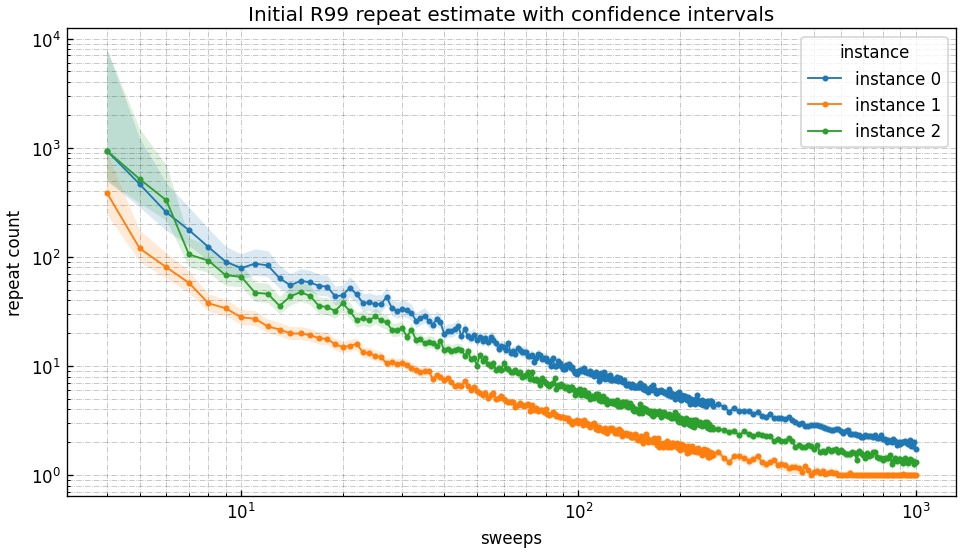

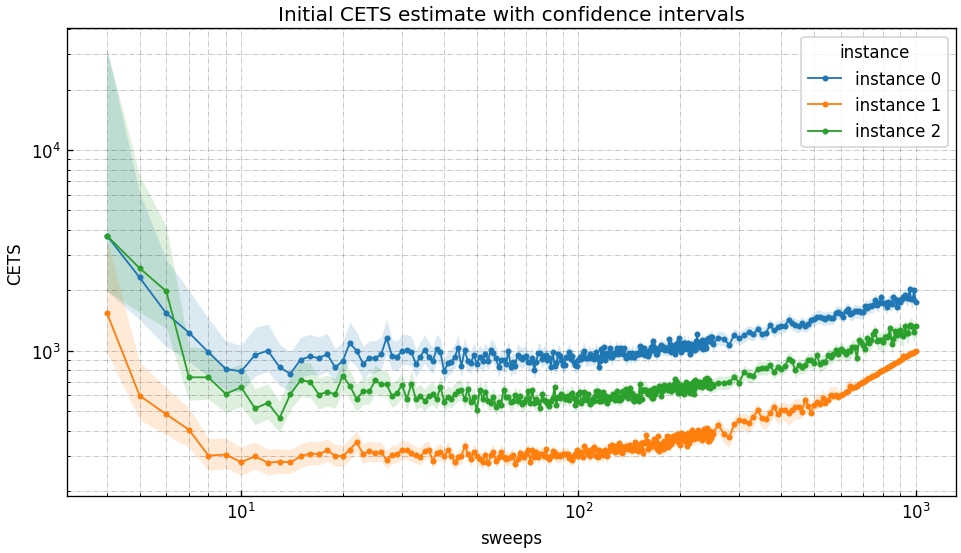

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120})
plot_report = (
    report.sort_values(["instance", "sweeps"])
    .replace([np.inf, -np.inf], np.nan)
)


# Infinite upper intervals occur when no successes are observed. They are important
# diagnostics, but they cannot be drawn on a finite log-scale plot.
def _finite_interval_frame(frame, metric, lower, upper):
    columns = ["instance", "sweeps", metric, lower, upper]
    return frame.dropna(subset=[metric, lower, upper]).loc[:, columns]


def _plot_metric_interval(frame, metric, lower, upper, ylabel, title):
    interval_frame = _finite_interval_frame(frame, metric, lower, upper)
    fig, ax = plt.subplots(figsize=(8, 4.6), constrained_layout=True)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for color_index, (instance_id, group) in enumerate(interval_frame.groupby("instance", sort=True)):
        group = group.sort_values("sweeps")
        color = colors[color_index % len(colors)]
        sweeps = group["sweeps"].to_numpy(dtype=float)
        estimates = group[metric].to_numpy(dtype=float)
        lower_bounds = group[lower].to_numpy(dtype=float)
        upper_bounds = group[upper].to_numpy(dtype=float)
        ax.plot(
            sweeps,
            estimates,
            marker="o",
            markersize=2.6,
            linewidth=1.1,
            color=color,
            label=f"instance {instance_id}",
        )
        ax.fill_between(
            sweeps,
            lower_bounds,
            upper_bounds,
            color=color,
            alpha=0.16,
            linewidth=0,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("sweeps")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(title="instance")
    return fig, ax


r99_fig, r99_ax = _plot_metric_interval(
    plot_report,
    "R99",
    "R99_ci_lower",
    "R99_ci_upper",
    "repeat count",
    "Initial R99 repeat estimate with confidence intervals",
)
cets_fig, cets_ax = _plot_metric_interval(
    plot_report,
    "CETS",
    "CETS_ci_lower",
    "CETS_ci_upper",
    "CETS",
    "Initial CETS estimate with confidence intervals",
)
plt.show()


The next plot turns the intervals into an experiment-design decision. The left panel asks how many repeats would be needed for a 10 percent maximum relative-error target; the right panel shows where the current interval misses that target.


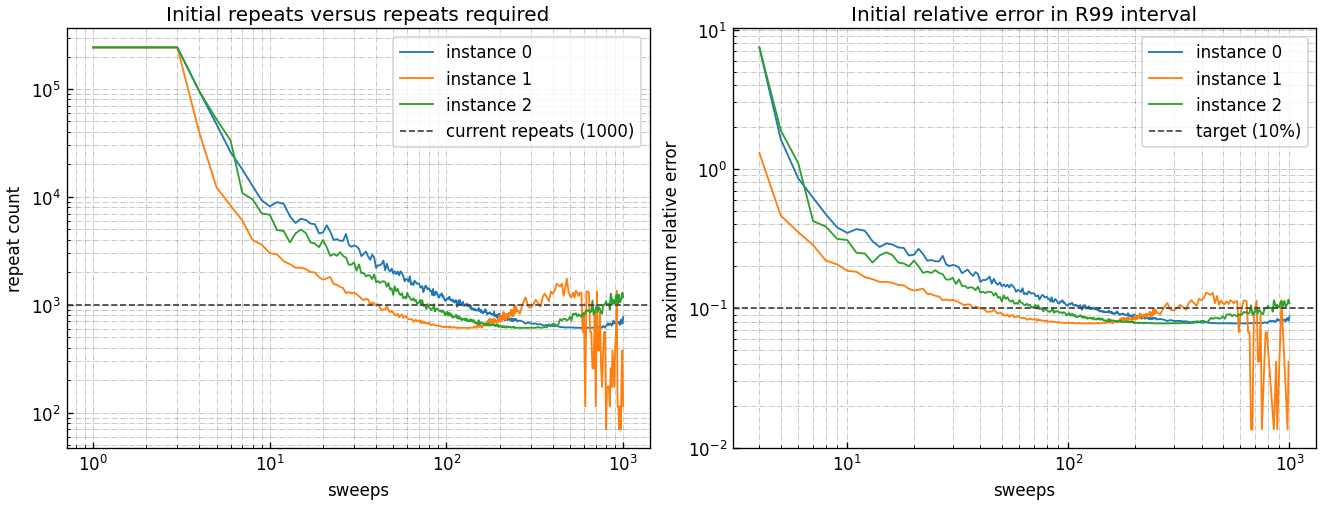

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
relative_error_threshold = float(report["relative_error_threshold"].iloc[0])

for color_index, (instance_id, group) in enumerate(plot_report.groupby("instance", sort=True)):
    group = group.sort_values("sweeps")
    color = colors[color_index % len(colors)]
    sweeps = group["sweeps"].to_numpy(dtype=float)
    axes[0].plot(
        sweeps,
        group["required_repeats"].to_numpy(dtype=float),
        color=color,
        linewidth=1.1,
        label=f"instance {instance_id}",
    )

    error_frame = group.loc[group["maximum_relative_error"].gt(0), ["sweeps", "maximum_relative_error"]].dropna()
    axes[1].plot(
        error_frame["sweeps"].to_numpy(dtype=float),
        error_frame["maximum_relative_error"].to_numpy(dtype=float),
        color=color,
        linewidth=1.1,
        label=f"instance {instance_id}",
    )

current_repeats = int(plot_report["current_repeats"].dropna().iloc[0])
axes[0].axhline(
    current_repeats,
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    label=f"current repeats ({current_repeats})",
)
axes[1].axhline(
    relative_error_threshold,
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    label=f"target ({relative_error_threshold:.0%})",
)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("sweeps")
axes[0].set_ylabel("repeat count")
axes[0].set_title("Initial repeats versus repeats required")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("sweeps")
axes[1].set_ylabel("maximum relative error")
axes[1].set_title("Initial relative error in R99 interval")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend()
plt.show()


## Step 4: Check whether the apparent best strategy is reliable

The reliability framework in Noori et al. highlights a subtle failure mode: `CETSopt` and the apparent optimal iteration count can move when estimates are noisy. Here we compare two choices for each instance: the sweep count with the smallest point-estimate `CETS`, and the best sweep count after requiring the 10 percent reliability target. If these disagree, the apparent optimum is still provisional.


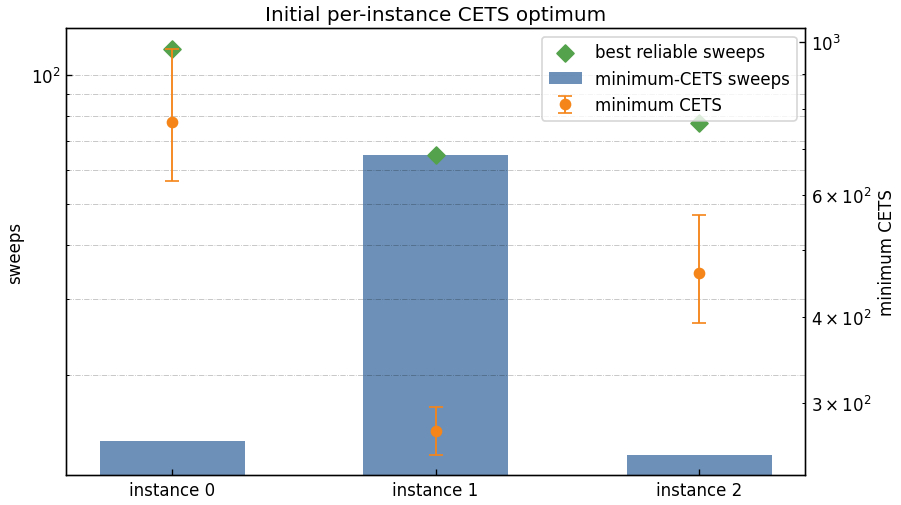

,instance,point_estimate_best_sweeps,R99,R99_ci_lower,R99_ci_upper,CETS,CETS_ci_lower,CETS_ci_upper,maximum_relative_error,required_repeats,reliability_status
46,0,14,54.793428,44.913922,69.887126,767.107998,628.794906,978.419770,0.275465,5722,needs_more_trials
577,1,65,4.206733,3.882995,4.554694,273.437643,252.394660,296.055133,0.082715,694,reliable
685,2,13,35.564674,30.147138,43.140935,462.340767,391.912795,560.832161,0.213028,3784,needs_more_trials


,instance,point_estimate_best_sweeps,R99,R99_ci_lower,R99_ci_upper,CETS,CETS_ci_lower,CETS_ci_upper,maximum_relative_error,required_repeats,reliability_status,best_reliable_sweeps,best_reliable_CETS,best_reliable_maximum_relative_error,best_reliable_required_repeats,same_sweep_when_requiring_reliability
0,0,14,54.793428,44.913922,69.887126,767.107998,628.794906,978.419770,0.275465,5722,needs_more_trials,115,828.965587,0.097685,957,False
1,1,65,4.206733,3.882995,4.554694,273.437643,252.394660,296.055133,0.082715,694,reliable,65,273.437643,0.082715,694,True
2,2,13,35.564674,30.147138,43.140935,462.340767,391.912795,560.832161,0.213028,3784,needs_more_trials,77,517.503282,0.095198,912,False


In [5]:
def best_point_rows(frame):
    return (
        frame.dropna(subset=["CETS", "CETS_ci_lower", "CETS_ci_upper"])
        .sort_values(["instance", "CETS", "sweeps"])
        .groupby("instance", group_keys=False)
        .head(1)
        .sort_values("instance")
    )


def best_reliable_rows(frame):
    return (
        frame[frame["reliability_status"].eq("reliable")]
        .dropna(subset=["CETS", "CETS_ci_lower", "CETS_ci_upper"])
        .sort_values(["instance", "CETS", "sweeps"])
        .groupby("instance", group_keys=False)
        .head(1)
        .sort_values("instance")
    )


optimal_rows = best_point_rows(plot_report)
reliable_optimal_rows = best_reliable_rows(plot_report)
assert set(reliable_optimal_rows["instance"]) == set(optimal_rows["instance"])

x = np.arange(len(optimal_rows))
cets_estimates = optimal_rows["CETS"].to_numpy(dtype=float)
cets_lower_errors = np.maximum(
    cets_estimates - optimal_rows["CETS_ci_lower"].to_numpy(dtype=float),
    0.0,
)
cets_upper_errors = np.maximum(
    optimal_rows["CETS_ci_upper"].to_numpy(dtype=float) - cets_estimates,
    0.0,
)

fig, ax_sweeps = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
ax_sweeps.bar(
    x,
    optimal_rows["sweeps"].to_numpy(dtype=float),
    width=0.55,
    color="#4c78a8",
    alpha=0.82,
    label="minimum-CETS sweeps",
)
ax_sweeps.scatter(
    x,
    reliable_optimal_rows["sweeps"].to_numpy(dtype=float),
    color="#54a24b",
    marker="D",
    s=52,
    zorder=3,
    label="best reliable sweeps",
)
ax_sweeps.set_yscale("log")
ax_sweeps.set_ylabel("sweeps")
ax_sweeps.set_xticks(x, [f"instance {int(instance)}" for instance in optimal_rows["instance"]])
ax_sweeps.grid(True, axis="y", which="both", alpha=0.25)

ax_cets = ax_sweeps.twinx()
ax_cets.errorbar(
    x,
    cets_estimates,
    yerr=np.vstack([cets_lower_errors, cets_upper_errors]),
    fmt="o",
    color="#f58518",
    capsize=4,
    linewidth=1.1,
    label="minimum CETS",
)
ax_cets.set_yscale("log")
ax_cets.set_ylabel("minimum CETS")
ax_cets.set_title("Initial per-instance CETS optimum")

handles, labels = ax_sweeps.get_legend_handles_labels()
cets_handles, cets_labels = ax_cets.get_legend_handles_labels()
ax_cets.legend(handles + cets_handles, labels + cets_labels, loc="upper right")
plt.show()

optimal_summary = optimal_rows.loc[
    :,
    [
        "instance",
        "sweeps",
        "R99",
        "R99_ci_lower",
        "R99_ci_upper",
        "CETS",
        "CETS_ci_lower",
        "CETS_ci_upper",
        "maximum_relative_error",
        "required_repeats",
        "reliability_status",
    ],
].rename(columns={"sweeps": "point_estimate_best_sweeps"})

reliable_summary = reliable_optimal_rows.loc[
    :,
    ["instance", "sweeps", "CETS", "maximum_relative_error", "required_repeats"],
].rename(
    columns={
        "sweeps": "best_reliable_sweeps",
        "CETS": "best_reliable_CETS",
        "maximum_relative_error": "best_reliable_maximum_relative_error",
        "required_repeats": "best_reliable_required_repeats",
    }
)
strategy_comparison = optimal_summary.merge(reliable_summary, on="instance", how="left")
strategy_comparison["same_sweep_when_requiring_reliability"] = (
    strategy_comparison["point_estimate_best_sweeps"]
    == strategy_comparison["best_reliable_sweeps"]
)

display(optimal_summary)
strategy_comparison


## Step 5: Add targeted reruns for the contenders

The initial report also tells us where more data would be useful. Instead of rerunning every sweep, we focus on the settings most likely to affect the recommendation: the top 10 initial `CETS` candidates per instance, plus one adaptive challenger that became relevant after the first rerun. The committed fixture `results/targeted_sa_reruns.npz` contains these additional energies, and `results/targeted_sa_reruns_metadata.json` records the sampler and selection rule.

The notebook loads the rerun data instead of executing the sampler so that tutorial verification remains fast and deterministic. The extra data were generated with `neal.SimulatedAnnealingSampler`, using the same seeded dense Ising model construction as the original SA tutorial.


In [6]:
from reliability_analysis import load_targeted_rerun_runs

candidate_count = 10
initial_candidates = (
    report.sort_values(["instance", "CETS", "sweeps"])
    .groupby("instance", group_keys=False)
    .head(candidate_count)
    .loc[
        :,
        [
            "instance",
            "sweeps",
            "current_repeats",
            "required_repeats",
            "additional_repeats_required",
            "CETS",
            "CETS_ci_lower",
            "CETS_ci_upper",
            "reliability_status",
        ],
    ]
    .reset_index(drop=True)
)

metadata_path = example_dir / "results" / "targeted_sa_reruns_metadata.json"
rerun_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
targeted_extra_runs = load_targeted_rerun_runs(example_dir)
assert rerun_metadata["data_file"] == "targeted_sa_reruns.npz"
assert not targeted_extra_runs.empty

extra_counts = (
    targeted_extra_runs.groupby(["instance", "sweeps"])
    .size()
    .rename("extra_repeats")
    .reset_index()
)
rerun_plan = initial_candidates.merge(extra_counts, on=["instance", "sweeps"], how="left")
rerun_plan["extra_repeats"] = rerun_plan["extra_repeats"].fillna(0).astype(int)
rerun_plan["total_repeats_after_rerun"] = rerun_plan["current_repeats"] + rerun_plan["extra_repeats"]

adaptive_targets = pd.DataFrame(rerun_metadata.get("adaptive_targets", []))
print(rerun_metadata["selection_rule"])
print(rerun_metadata["adaptive_selection_rule"])
print(f"Committed extra SA repeats: {len(targeted_extra_runs):,}")

display(rerun_plan)
adaptive_targets


top 10 rows by initial CETS per instance
After the first rerun, add repeats for any still-unreliable row whose point CETS is lower than the current best reliable CETS.
Committed extra SA repeats: 279,000


,instance,sweeps,current_repeats,required_repeats,additional_repeats_required,CETS,CETS_ci_lower,CETS_ci_upper,reliability_status,extra_repeats,total_repeats_after_rerun
0,0,14,1000,5722,4722,767.107998,628.794906,978.419770,needs_more_trials,9000,10000
1,0,10,1000,8153,7153,788.907824,625.218374,1063.032610,needs_more_trials,9000,10000
2,0,40,1000,2193,1193,789.411577,693.616947,911.346636,needs_more_trials,9000,10000
3,0,74,1000,1306,306,800.806123,722.533477,893.314231,needs_more_trials,9000,10000
4,0,9,1000,9302,8302,812.536840,635.085870,1121.492456,needs_more_trials,9000,10000
5,0,19,1000,4580,3580,825.808616,689.761305,1023.561191,needs_more_trials,9000,10000
6,0,63,1000,1534,534,827.344871,740.895386,931.794585,needs_more_trials,9000,10000
7,0,58,1000,1647,647,827.518857,738.454554,936.201814,needs_more_trials,9000,10000
8,0,115,1000,957,0,828.965587,757.490094,909.943425,reliable,9000,10000
9,0,13,1000,6629,5629,829.210853,670.637866,1080.379873,needs_more_trials,9000,10000


,instance,sweeps,existing_repeats,additional_repeats,CETS_before_adaptive_rerun,best_reliable_CETS_before_adaptive_rerun
0,0,83,1000,9000,831.537619,834.792139


## Step 6: Compare the recommendation before and after reruns

Now we rerun the reliability report after appending the targeted extra energies. The first 1000-repeat report was useful for finding the uncertain contenders; after those contenders have enough repeats, the reliability-gated recommendation can move.


In [7]:
combined_runs = pd.concat([runs, targeted_extra_runs], ignore_index=True)
combined_reliability_runs = attach_quality_thresholds(
    combined_runs,
    instance_baselines,
    quality_target=quality_target,
)

after_report = run_reliability_analysis(
    make_benchmark(),
    combined_reliability_runs,
    quality_target=quality_target,
    relative_error_threshold=0.10,
)
after_plot_report = (
    after_report.sort_values(["instance", "sweeps"])
    .replace([np.inf, -np.inf], np.nan)
)

targeted_settings = extra_counts.loc[:, ["instance", "sweeps"]]
targeted_after = after_report.merge(targeted_settings, on=["instance", "sweeps"], how="inner")
assert targeted_after["reliability_status"].eq("reliable").all()

initial_point = optimal_summary.loc[
    :,
    ["instance", "point_estimate_best_sweeps", "CETS", "reliability_status"],
].rename(
    columns={
        "CETS": "initial_point_estimate_CETS",
        "reliability_status": "initial_point_estimate_status",
    }
)
initial_reliable = reliable_summary.loc[
    :,
    ["instance", "best_reliable_sweeps", "best_reliable_CETS"],
].rename(
    columns={
        "best_reliable_sweeps": "initial_reliable_sweeps",
        "best_reliable_CETS": "initial_reliable_CETS",
    }
)
after_reliable_rows = best_reliable_rows(after_plot_report)
after_reliable = after_reliable_rows.loc[
    :,
    [
        "instance",
        "sweeps",
        "current_repeats",
        "CETS",
        "CETS_ci_lower",
        "CETS_ci_upper",
        "maximum_relative_error",
    ],
].rename(
    columns={
        "sweeps": "after_rerun_reliable_sweeps",
        "current_repeats": "after_rerun_repeats",
        "CETS": "after_rerun_CETS",
        "CETS_ci_lower": "after_rerun_CETS_ci_lower",
        "CETS_ci_upper": "after_rerun_CETS_ci_upper",
        "maximum_relative_error": "after_rerun_maximum_relative_error",
    }
)

rerun_strategy_comparison = (
    initial_point.merge(initial_reliable, on="instance")
    .merge(after_reliable, on="instance")
)
rerun_strategy_comparison["recommendation_changed_after_rerun"] = (
    rerun_strategy_comparison["initial_reliable_sweeps"]
    != rerun_strategy_comparison["after_rerun_reliable_sweeps"]
)

lower_unreliable_challengers = []
for instance_id, group in after_report.groupby("instance"):
    best_row = after_reliable_rows[after_reliable_rows["instance"].eq(instance_id)].iloc[0]
    challengers = group[
        group["reliability_status"].ne("reliable")
        & group["CETS"].le(best_row["CETS"])
    ]
    lower_unreliable_challengers.append(
        {
            "instance": instance_id,
            "after_rerun_reliable_sweeps": int(best_row["sweeps"]),
            "lower_unreliable_challengers": int(len(challengers)),
        }
    )
challenger_summary = pd.DataFrame(lower_unreliable_challengers)
assert challenger_summary["lower_unreliable_challengers"].eq(0).all()

display(rerun_strategy_comparison)
challenger_summary


,instance,point_estimate_best_sweeps,initial_point_estimate_CETS,initial_point_estimate_status,initial_reliable_sweeps,initial_reliable_CETS,after_rerun_reliable_sweeps,after_rerun_repeats,after_rerun_CETS,after_rerun_CETS_ci_lower,after_rerun_CETS_ci_upper,after_rerun_maximum_relative_error,recommendation_changed_after_rerun
0,0,14,767.107998,needs_more_trials,115,828.965587,10,10000,834.792139,769.540019,911.742153,0.092179,True
1,1,65,273.437643,reliable,65,273.437643,37,1000,283.128917,258.302140,311.424410,0.099939,True
2,2,13,462.340767,needs_more_trials,77,517.503282,108,1000,541.887643,498.996072,588.795539,0.086564,True


,instance,after_rerun_reliable_sweeps,lower_unreliable_challengers
0,0,10,0
1,1,37,0
2,2,108,0


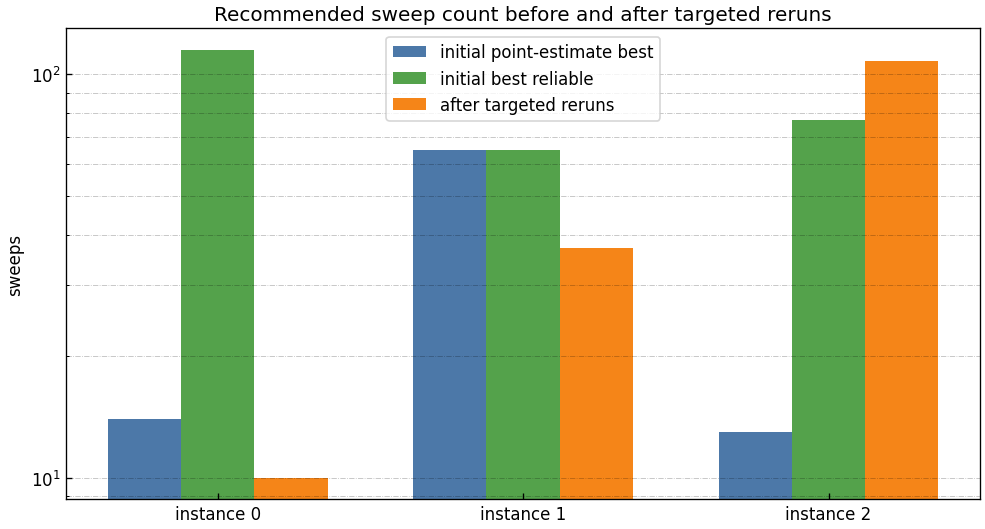

,instance,sweeps,current_repeats,required_repeats,CETS,CETS_ci_lower,CETS_ci_upper,maximum_relative_error,reliability_status
0,0,10,10000,8616,834.792139,769.540019,911.742153,0.092179,reliable
10,0,9,10000,9809,857.699200,786.570930,942.562707,0.098943,reliable
2,0,13,10000,6856,858.401786,797.983067,928.319644,0.081451,reliable
3,0,14,10000,6442,867.005616,807.706130,935.299817,0.078770,reliable
6,0,58,10000,1773,900.805419,866.949286,936.977439,0.040155,reliable
12,1,12,10000,2613,287.040986,274.126405,301.098776,0.048975,reliable
14,1,14,10000,2276,287.935475,275.784793,301.070631,0.045618,reliable
11,1,10,10000,3108,288.501850,274.428945,303.962708,0.053590,reliable
19,1,65,10000,717,292.637291,285.247065,300.214478,0.025893,reliable
18,1,57,10000,770,292.991718,285.386247,300.821583,0.026724,reliable


In [8]:
fig, ax = plt.subplots(figsize=(8.2, 4.4), constrained_layout=True)
x = np.arange(len(rerun_strategy_comparison))
width = 0.24

ax.bar(
    x - width,
    rerun_strategy_comparison["point_estimate_best_sweeps"].to_numpy(dtype=float),
    width=width,
    label="initial point-estimate best",
    color="#4c78a8",
)
ax.bar(
    x,
    rerun_strategy_comparison["initial_reliable_sweeps"].to_numpy(dtype=float),
    width=width,
    label="initial best reliable",
    color="#54a24b",
)
ax.bar(
    x + width,
    rerun_strategy_comparison["after_rerun_reliable_sweeps"].to_numpy(dtype=float),
    width=width,
    label="after targeted reruns",
    color="#f58518",
)
ax.set_yscale("log")
ax.set_ylabel("sweeps")
ax.set_xticks(
    x,
    [f"instance {int(instance)}" for instance in rerun_strategy_comparison["instance"]],
)
ax.set_title("Recommended sweep count before and after targeted reruns")
ax.grid(True, axis="y", which="both", alpha=0.25)
ax.legend()
plt.show()

targeted_after_summary = targeted_after.loc[
    :,
    [
        "instance",
        "sweeps",
        "current_repeats",
        "required_repeats",
        "CETS",
        "CETS_ci_lower",
        "CETS_ci_upper",
        "maximum_relative_error",
        "reliability_status",
    ],
].sort_values(["instance", "CETS", "sweeps"])

targeted_after_summary.groupby("instance").head(5)


## Step 7: Summarize the reliability result

The initial data are enough to diagnose uncertainty in the low-`CETS` region, but not enough to finalize every contender. After the targeted reruns, all rerun contender settings meet the 10 percent relative-error target, and no still-unreliable row has a lower point-estimate `CETS` than the after-rerun best reliable setting for its instance. Rows outside this decision region may still need more repeats before making broader claims about the full sweep grid.


In [9]:
initial_status_summary = (
    report["reliability_status"]
    .value_counts()
    .rename_axis("reliability_status")
    .reset_index(name="initial_rows")
)
after_status_summary = (
    after_report["reliability_status"]
    .value_counts()
    .rename_axis("reliability_status")
    .reset_index(name="after_rerun_rows")
)
status_summary = initial_status_summary.merge(
    after_status_summary,
    on="reliability_status",
    how="outer",
).fillna(0)
status_summary[["initial_rows", "after_rerun_rows"]] = status_summary[
    ["initial_rows", "after_rerun_rows"]
].astype(int)

initial_unresolved_rows = int(report["statistically_unresolved"].sum())
after_unresolved_rows = int(after_report["statistically_unresolved"].sum())
current_repeats = int(report["current_repeats"].dropna().iloc[0])
targeted_setting_count = len(targeted_settings)
print(f"Initial rows with statistically unresolved intervals: {initial_unresolved_rows}")
print(f"After-rerun rows with statistically unresolved intervals: {after_unresolved_rows}")
print(f"Initial repeats per sweep setting: {current_repeats}")
print(f"Targeted contender settings rerun to reliability: {targeted_setting_count}")
status_summary


Initial rows with statistically unresolved intervals: 102
After-rerun rows with statistically unresolved intervals: 102
Initial repeats per sweep setting: 1000
Targeted contender settings rerun to reliability: 31


,reliability_status,initial_rows,after_rerun_rows
0,needs_more_trials,293,273
1,reliable,682,702


## Comparison with Noori et al.

Reference: Moslem Noori, Elisabetta Valiante, Ignacio Rozada, Thomas Van Vaerenbergh, and Masoud Mohseni, "Statistical analysis for per-instance evaluation of stochastic optimizers: Avoiding unreliable conclusions," *Physical Review Applied* 25, no. 3 (2026): 034081; arXiv:2503.16589v2.

Noori et al. study SAT data and vary the repeat count across full experiment panels. This notebook studies SA data and reruns only the decision-relevant contenders, so it is a worked example rather than a reproduction of those figures. The comparison to check is qualitative: confidence intervals and required-repeat diagnostics should warn us against over-trusting point estimates for `R99`, `CETS`, and the apparent optimal stopping strategy. Once the contender settings have enough data, the recommendation can become both different and better supported.


In [10]:
finite_relative_error = report["maximum_relative_error"].replace([np.inf, -np.inf], np.nan)
required_quantiles = report["required_repeats"].quantile([0.5, 0.75, 0.9, 0.99]).astype(int)
needs_more_rows = int(report["reliability_status"].eq("needs_more_trials").sum())
reliable_rows = int(report["reliability_status"].eq("reliable").sum())
after_needs_more_rows = int(after_report["reliability_status"].eq("needs_more_trials").sum())
after_reliable_rows_count = int(after_report["reliability_status"].eq("reliable").sum())
nonfinite_upper_intervals = int(report["R99_ci_upper"].replace([np.inf, -np.inf], np.nan).isna().sum())
changed_strategy_rows = strategy_comparison.loc[
    ~strategy_comparison["same_sweep_when_requiring_reliability"],
    ["instance", "point_estimate_best_sweeps", "best_reliable_sweeps"],
]
after_changed_rows = rerun_strategy_comparison.loc[
    rerun_strategy_comparison["recommendation_changed_after_rerun"],
    ["instance", "initial_reliable_sweeps", "after_rerun_reliable_sweeps"],
]

def _yes_no(value):
    return "yes" if bool(value) else "no"

reference_alignment = pd.DataFrame(
    [
        {
            "Noori et al. takeaway": "Point estimates of R99 can be misleading when the repeat count is insufficient.",
            "this notebook": (
                f"With {current_repeats} repeats, {needs_more_rows} of {len(report)} sweep settings "
                f"still need more repeats; {nonfinite_upper_intervals} settings have non-finite R99 upper intervals."
            ),
            "alignment": "Aligned",
        },
        {
            "Noori et al. takeaway": "Confidence intervals shrink and comparisons become more dependable as repeats increase.",
            "this notebook": (
                f"The required-repeat diagnostic estimates a median of {required_quantiles.loc[0.5]} repeats, "
                f"75th percentile of {required_quantiles.loc[0.75]}, 90th percentile of {required_quantiles.loc[0.9]}, "
                f"and 99th percentile of {required_quantiles.loc[0.99]} to hit the 10 percent target. "
                f"After targeted reruns, all {targeted_setting_count} contender settings are reliable."
            ),
            "alignment": "Aligned, using targeted n=10000-style reruns instead of full-grid panels",
        },
        {
            "Noori et al. takeaway": "CETSopt and the optimal stopping strategy can change when estimates are noisy.",
            "this notebook": (
                f"The minimum-CETS sweep changes after requiring reliability for "
                f"{len(changed_strategy_rows)} of {len(strategy_comparison)} instances. "
                f"After adding enough contender data, the reliability-gated recommendation changes for "
                f"{len(after_changed_rows)} of {len(rerun_strategy_comparison)} instances."
            ),
            "alignment": "Aligned",
        },
        {
            "Noori et al. takeaway": "Use confidence intervals and repeat planning before comparing stochastic optimizers.",
            "this notebook": (
                f"The initial report says {reliable_rows} rows are reliable and {needs_more_rows} need reruns. "
                f"After targeted reruns, {after_reliable_rows_count} rows are reliable and {after_needs_more_rows} remain outside the decision-ready region. "
                f"Any lower-CETS unresolved challenger after rerun? {_yes_no(not challenger_summary['lower_unreliable_challengers'].eq(0).all())}."
            ),
            "alignment": "Aligned",
        },
    ]
)

display(changed_strategy_rows.reset_index(drop=True))
display(after_changed_rows.reset_index(drop=True))
reference_alignment


,instance,point_estimate_best_sweeps,best_reliable_sweeps
0,0,14,115
1,2,13,77


,instance,initial_reliable_sweeps,after_rerun_reliable_sweeps
0,0,115,10
1,1,65,37
2,2,77,108


,Noori et al. takeaway,this notebook,alignment
0,Point estimates of R99 can be misleading when ...,"With 1000 repeats, 293 of 975 sweep settings s...",Aligned
1,Confidence intervals shrink and comparisons be...,The required-repeat diagnostic estimates a med...,"Aligned, using targeted n=10000-style reruns i..."
2,CETSopt and the optimal stopping strategy can ...,The minimum-CETS sweep changes after requiring...,Aligned
3,Use confidence intervals and repeat planning b...,The initial report says 682 rows are reliable ...,Aligned
